In [1]:
from collections import namedtuple

import numpy as np

from viz_map import MapVisualization

In [2]:
TOWN = "Town01"
Args = namedtuple("Args", ["host", "port", "map"])
args = Args(host="localhost", port=2000, map=TOWN)

In [3]:
# viz = MapVisualization(args)
# viz.draw_roads()
# # viz.draw_spawn_points()
# viz.destroy()

In [4]:
# viz.fig.savefig(f"./{args.map}.pdf", format="pdf", bbox_inches="tight")
# ax = viz.ax

In [5]:
# client = viz.carla_client

In [6]:
import carla

client = carla.Client(args.host, args.port, worker_threads=1)
client.set_timeout(30.0)
client.load_world(args.map)


# Set the spectator with our transform
world = client.get_world()

carla_map = world.get_map()
carla_map.save_to_disk(f"./{args.map}.xodr")

In [7]:
# points = np.arange(-10, 200, 1)
# for p in points:
#     loc = carla.Location(x=float(p), y=10.0, z=0.0)
#     wp = carla_map.get_waypoint(loc, project_to_road=True, lane_type=carla.LaneType.Driving)
#     location = wp.transform.location
#     world.debug.draw_string(location, "O", draw_shadow=False, life_time=60.0, persistent_lines=True)


In [8]:
landmarks = carla_map.get_all_landmarks()
locations_objs = [landmark.transform.location for landmark in landmarks]
locations = np.array([[loc.x, loc.y, loc.z] for loc in locations_objs])


# Get min and max x coords
MIN_X = np.min(locations[:, 0])
MAX_X = np.max(locations[:, 0])

# Get min and max y coords
MIN_Y = np.min(locations[:, 1])
MAX_Y = np.max(locations[:, 1])

# Get min and max z coords
MIN_Z = np.min(locations[:, 2])
MAX_Z = np.max(locations[:, 2])

print(
    f"Feature ranges: x: {MIN_X:2f} to {MAX_X:2f}, y: {MIN_Y:2f} to {MAX_Y:2f}, z: {MIN_Z:2f} to {MAX_Z:2f}"
)

Feature ranges: x: -4.560000 to 398.899994, y: -4.478962 to 333.609955, z: -0.699043 to 0.152305


In [9]:
spec_x = (MAX_X - MIN_X) / 2
spec_y = (MAX_Y - MIN_Y) / 2
bev_transform = carla.Transform(
    carla.Location(x=spec_x, y=spec_y, z=300), carla.Rotation(pitch=-90, yaw=0, roll=0)
)
world.get_spectator().set_transform(bev_transform)

In [39]:
from PCLA import location_to_waypoint
from pcla_functions.spawn_points import draw_spawn_points

In [11]:
vehicle_spawn_points = carla_map.get_spawn_points()

startLoc = vehicle_spawn_points[31].location  # Define Start location
endLoc = vehicle_spawn_points[78].location  # Define End location
# waypoints = location_to_waypoint(client, startLoc, endLoc, draw=True)
# waypoints

In [12]:
draw_spawn_points(world)

In [13]:
def loc_to_str(loc):
    return f"({loc.x:.2f}, {loc.y:.2f}, {loc.z:.2f})"


# loc_to_str(loc)

In [97]:
# loc = carla.Location(x=-7.5, y=220.0, z=0.0)
# loc = carla.Location(x=-6, y=200.0, z=0.0)
loc = carla.Location(x=0.0, y=0.0, z=0.0)
PROJECT = False
wp = carla_map.get_waypoint(loc, project_to_road=PROJECT, lane_type=carla.LaneType.Driving)
if wp:
    location = wp.transform.location
    print(f"Waypoint found for location: {loc_to_str(loc)} at {loc_to_str(location)}")
    world.debug.draw_string(location, "o", life_time=60.0, persistent_lines=True)
else:
    print(f"No waypoint found for location: {loc_to_str(loc)}")

Waypoint found for location: (0.00, 0.00, 0.00) at (1.15, 1.18, 0.00)


## Test points sampling

In [15]:
import torch

In [16]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from pprint import pformat


@dataclass
class NumericalFeature:
    name: str
    low: float
    high: float


class ProblemDomain(ABC):
    def __init__(
        self,
        features: list[NumericalFeature],
    ) -> None:
        self._features = features
        self._low = torch.tensor([f.low for f in features], dtype=torch.float32)
        self._high = torch.tensor([f.high for f in features], dtype=torch.float32)

    @property
    def n_dims(self) -> int:
        return len(self._features)

    @property
    def feature_names(self) -> list[str]:
        return [f.name for f in self._features]

    @property
    def low(self) -> torch.Tensor:
        return self._low

    @property
    def high(self) -> torch.Tensor:
        return self._high

    @property
    def features(self) -> list[NumericalFeature]:
        return self._features

    def bounds(self) -> tuple[torch.Tensor, torch.Tensor]:
        return (self._low, self._high)

    def sample(self) -> torch.Tensor:
        return torch.rand(self.n_dims) * (self._high - self._low) + self._low

    @abstractmethod
    def is_valid(self, x: torch.Tensor) -> bool:
        raise NotImplementedError

    def to_dict(self, x: torch.Tensor) -> dict:
        return {f.name: x[i].item() for i, f in enumerate(self._features)}

    def to_tensor(self, scenario_dict: dict) -> torch.Tensor:
        return torch.tensor([scenario_dict[f.name] for f in self._features], dtype=torch.float32)

    def __repr__(self) -> str:
        return f"{self.__class__.__name__}(\n  features={pformat(self._features, indent=4)}\n)"


In [100]:
class CarlaPointProblemDomain(ProblemDomain):
    def __init__(
        self,
    ) -> None:
        feat = []
        feat.append(NumericalFeature("start_x", MIN_X, MAX_X))
        feat.append(NumericalFeature("start_y", MIN_Y, MAX_Y))
        super().__init__(feat)

    def check_location(self, carla_loc: carla.Location) -> bool:
        PROJECT = False
        wp = carla_map.get_waypoint(carla_loc, project_to_road=PROJECT, lane_type=carla.LaneType.Driving)
        if wp and not wp.is_junction:
            location = wp.transform.location
            print(f"Waypoint found for location: {carla_loc!s} at {location!s}")
            return True
            # world.debug.draw_string(location, "o", life_time=60.0, persistent_lines=True)
        else:
            print(f"No waypoint found for location: {carla_loc!s}")
            return False

    def is_valid(self, x) -> bool:
        start_loc = carla.Location(float(x[0]), float(x[1]), 0.0)
        # goal_loc = carla.Location(float(x[2]), float(x[3]), 0.0)
        return self.check_location(start_loc)  # and self.check_location(goal_loc)


domain = CarlaPointProblemDomain()


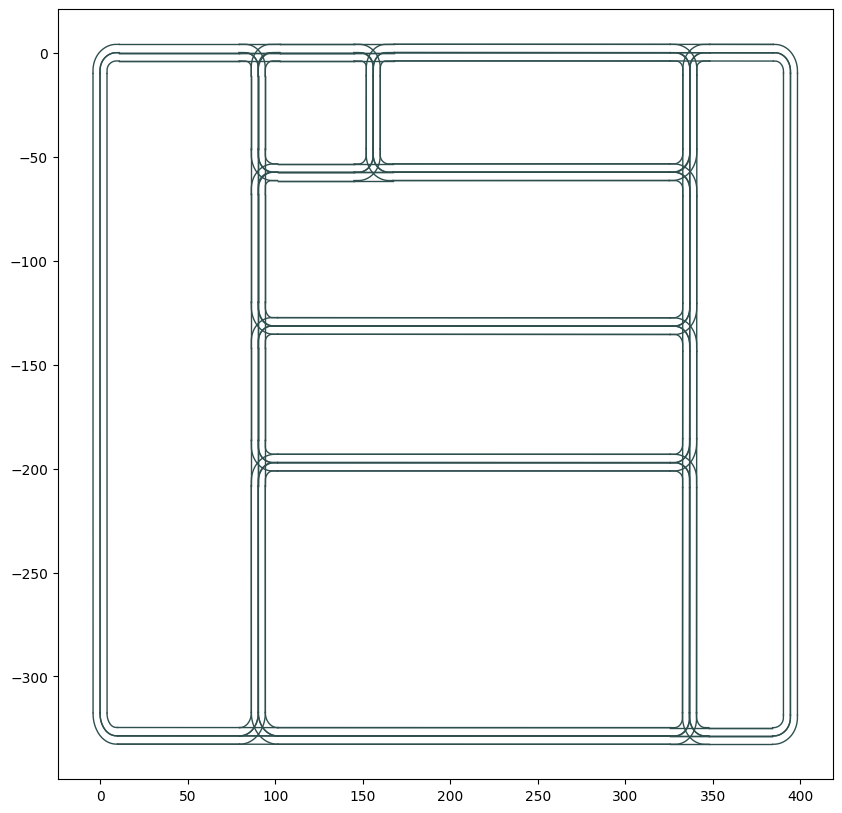

In [101]:
viz = MapVisualization(args)
viz.draw_roads()
# viz.draw_spawn_points()
viz.destroy()
ax = viz.ax
fig = viz.fig

Point (100.32, 151.75, 0.00) not valid
Waypoint found for location: (156.14, 16.30, 0.00) at (158.06, 16.30, 0.00)
Point (40.42, 311.30, 0.00) not valid
Point (55.63, 234.58, 0.00) not valid
Point (193.69, 78.40, 0.00) not valid
Point (376.25, 101.22, 0.00) not valid
Waypoint found for location: (312.75, 130.17, 0.00) at (312.75, 129.51, 0.00)
Point (38.59, 243.60, 0.00) not valid
Point (64.28, 79.82, 0.00) not valid
Point (151.00, 296.25, 0.00) not valid
Point (157.72, 299.80, 0.00) not valid
Point (284.32, 14.05, 0.00) not valid
Point (262.03, 88.51, 0.00) not valid
Point (170.61, 92.79, 0.00) not valid
Point (316.46, 62.99, 0.00) not valid
Waypoint found for location: (126.30, 135.31, 0.00) at (126.30, 133.43, 0.00)
Point (202.12, 228.38, 0.00) not valid
Point (170.22, 42.76, 0.00) not valid
Point (200.39, 256.65, 0.00) not valid
Point (64.38, 280.99, 0.00) not valid
Point (217.49, 142.49, 0.00) not valid
Waypoint found for location: (-0.09, 188.97, 0.00) at (-2.01, 188.97, 0.00)
Po

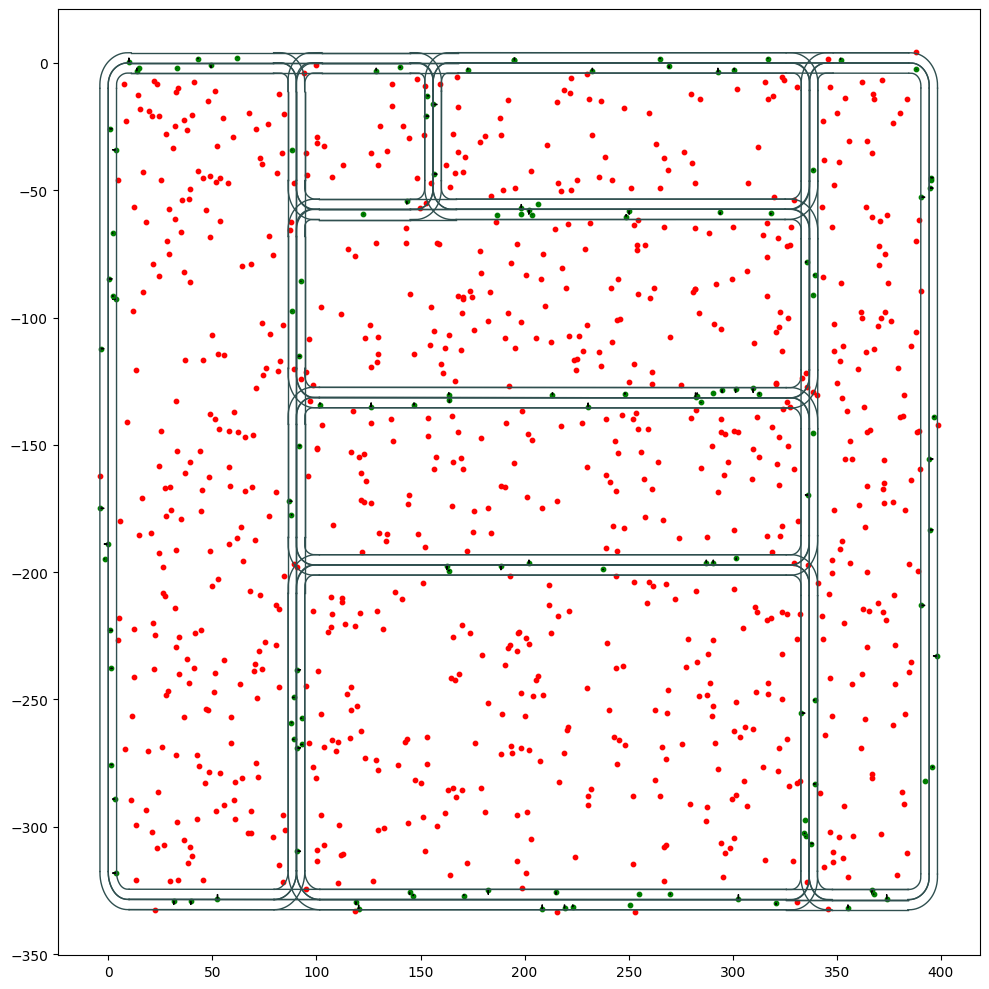

: 

In [ ]:
N_POINTS = 1000
for _ in range(N_POINTS):
    x = domain.sample()
    loc = carla.Location(x=x[0].item(), y=x[1].item(), z=0.0)
    plot_x = x[0].item()
    plot_y = -x[1].item()
    PROJECT = False
    wp = carla_map.get_waypoint(loc, project_to_road=PROJECT, lane_type=carla.LaneType.Driving)
    if wp and not wp.is_junction:
        wp_location = wp.transform.location
        print(f"Waypoint found for location: {loc_to_str(loc)} at {loc_to_str(wp_location)}")
        color = "green"
        ax.scatter(plot_x, plot_y, color=color, s=10, label="Sampled Point")
        world.debug.draw_string(
            wp_location, "o", life_time=60.0, persistent_lines=True, color=carla.Color(0, 150, 0)
        )
        ax.arrow(plot_x, plot_y, wp_location.x - plot_x, -wp_location.y - plot_y)

    else:
        print(f"Point {loc_to_str(loc)} not valid")
        color = "red"
        ax.scatter(plot_x, plot_y, color=color, s=10, label="Sampled Point")
        world.debug.draw_string(loc, "x", life_time=60.0, persistent_lines=True, color=carla.Color(255, 0, 0))

fig.tight_layout()
fig.savefig(f"./{args.map}_sampled_points.pdf", format="pdf", bbox_inches="tight")
fig

In [64]:
torch.dist(torch.tensor([1.0, 1.0]), torch.tensor([0.0, 0.0]))

tensor(1.4142)

In [90]:
valid_points = []
MIN_DISTANCE = 25.0
MAX_DISTANCE = 100.0

while len(valid_points) < 5:
    x = domain.sample()
    if domain.is_valid(x):
        if not valid_points:
            valid_points.append(x)
        else:
            dist_to_previous = torch.dist(x, valid_points[-1])
            if MIN_DISTANCE <= dist_to_previous <= MAX_DISTANCE:
                valid_points.append(x)


No waypoint found for location: Location(x=309.974213, y=276.086426, z=0.000000)
No waypoint found for location: Location(x=31.846861, y=33.628109, z=0.000000)
No waypoint found for location: Location(x=222.211182, y=51.439545, z=0.000000)
No waypoint found for location: Location(x=261.020447, y=87.583481, z=0.000000)
No waypoint found for location: Location(x=250.293015, y=213.152695, z=0.000000)
No waypoint found for location: Location(x=5.786017, y=119.338943, z=0.000000)
No waypoint found for location: Location(x=138.990631, y=302.388550, z=0.000000)
No waypoint found for location: Location(x=56.972687, y=229.149933, z=0.000000)
No waypoint found for location: Location(x=133.162643, y=150.976990, z=0.000000)
No waypoint found for location: Location(x=275.622406, y=253.657700, z=0.000000)
No waypoint found for location: Location(x=253.791504, y=276.602661, z=0.000000)
No waypoint found for location: Location(x=291.588928, y=275.324677, z=0.000000)
No waypoint found for location: Loc

In [91]:
valid_point_locations = [carla.Location(x=float(x[0]), y=float(x[1]), z=0.0) for x in valid_points]
valid_point_locations

In [92]:
from itertools import pairwise


In [93]:
def plot_locations(a: carla.Location, b: carla.Location, color=None):
    print(str(color))
    waypoints = location_to_waypoint(
        client,
        a,
        b,
        draw=True,
        color=color,
    )
    return waypoints


In [94]:
carla_colors = [
    carla.Color(20, 0, 0),
    carla.Color(0, 20, 0),
    carla.Color(0, 0, 20),
    carla.Color(20, 20, 0),
]

result = [plot_locations(a, b, color=c) for (a, b), c in zip(pairwise(valid_point_locations), carla_colors)]

Color(20,0,0,255)
Color(0,20,0,255)
Color(0,0,20,255)
Color(20,20,0,255)
